# Clasificación de Hongos Comestibles y Venenosos Mediante Aprendizaje Supervisado
**Proyecto Final — Modelos y Simulación de Sistemas 2**  
Rafael Alemán · Isabela Bedoya · Alejandro Gallego  
Ingeniería de Sistemas — Universidad de Antioquia

## 1. Importaciones y Configuración

In [ ]:
# ── Librerías estándar y científicas ──────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Estilo global de gráficos
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 150, "font.size": 10})

RANDOM_STATE = 42
N_SPLITS     = 5
print("Importaciones completadas.")

Importaciones completadas.


## 2. Carga del Dataset

In [ ]:
def load_data():
    """Descarga el dataset UCI Mushroom desde OpenML (ID 24)."""
    print("Descargando el dataset Mushroom desde OpenML (ID: 24)...")
    X, y = fetch_openml(data_id=24, as_frame=True, return_X_y=True, parser="auto")
    print(f"¡Descarga completada!  →  {X.shape[0]} muestras, {X.shape[1]} características.")
    return X, y

X_raw, y_raw = load_data()

Descargando el dataset Mushroom desde OpenML (ID: 24)...
¡Descarga completada!  →  8124 muestras, 22 características.


## 3. Exploración de Datos (EDA)


EXPLORACIÓN DE DATOS
Dimensiones iniciales: 8124 muestras × 22 características

 Valores faltantes:
stalk-root    2480
dtype: int64


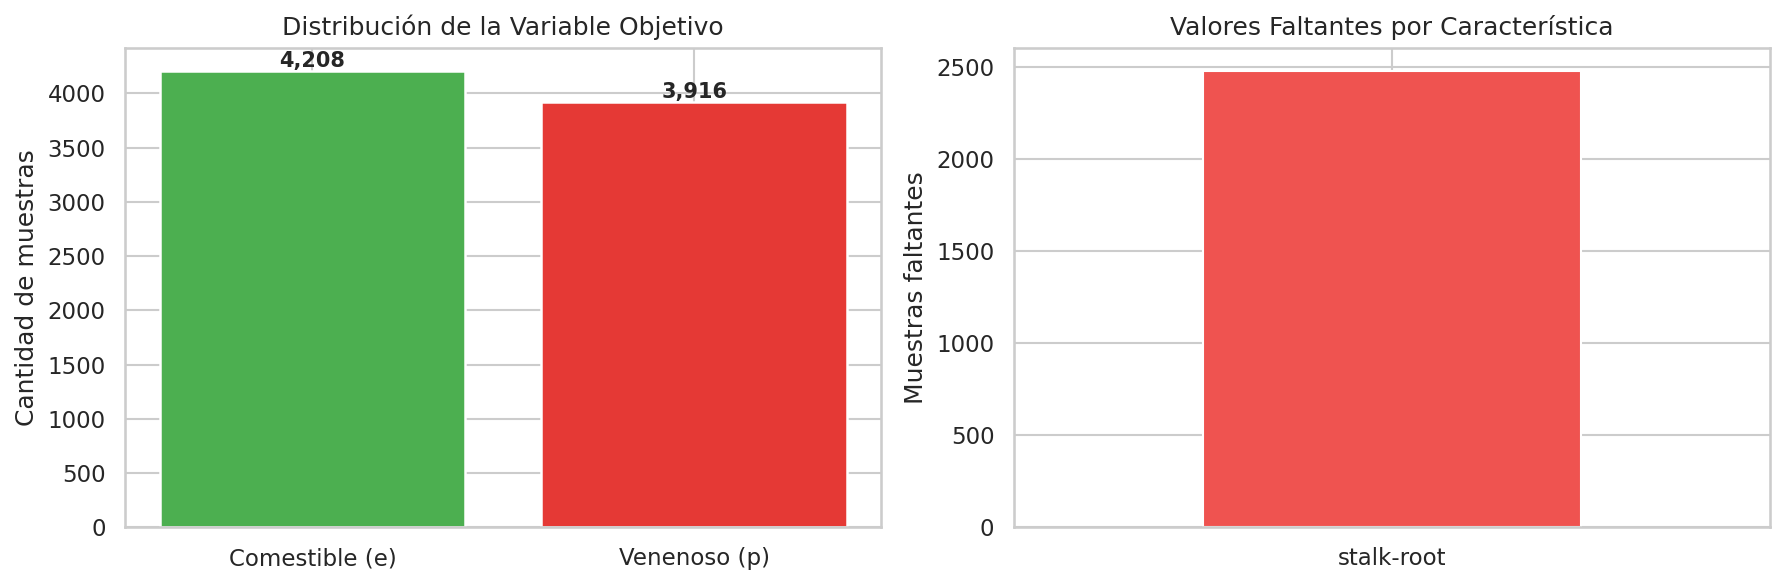


 Características con un solo valor (se eliminarán): ['veil-type']


In [ ]:
def explore_data(X, y):
    """EDA: distribución de clases, valores faltantes y varianza cero."""
    print("\n" + "="*50)
    print("EXPLORACIÓN DE DATOS")
    print("="*50)
    print(f"Dimensiones iniciales: {X.shape[0]} muestras × {X.shape[1]} características")

    # --- 1. Distribución de clases ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    counts = y.value_counts()
    colors = ["#4CAF50", "#E53935"]
    axes[0].bar(["Comestible (e)", "Venenoso (p)"],
                [counts.get("e", 0), counts.get("p", 0)],
                color=colors, edgecolor="white", linewidth=1.2)
    axes[0].set_title("Distribución de la Variable Objetivo")
    axes[0].set_ylabel("Cantidad de muestras")
    for bar in axes[0].patches:
        axes[0].annotate(f"{int(bar.get_height()):,}",
                         (bar.get_x() + bar.get_width()/2, bar.get_height()),
                         ha="center", va="bottom", fontweight="bold")

    # --- 2. Valores faltantes ---
    missing = X.isnull().sum()
    missing = missing[missing > 0]
    if not missing.empty:
        missing.plot(kind="bar", color="#EF5350", ax=axes[1])
        axes[1].set_title("Valores Faltantes por Característica")
        axes[1].set_ylabel("Muestras faltantes")
        axes[1].tick_params(axis="x", rotation=0)
        print(f"\n Valores faltantes:\n{missing}")
    else:
        axes[1].set_visible(False)
        print("\n No se encontraron valores faltantes.")

    plt.tight_layout()
    plt.savefig("eda_overview.png", bbox_inches="tight")
    plt.show()

    # --- 3. Características sin varianza ---
    single_val = X.nunique()[X.nunique() == 1].index.tolist()
    if single_val:
        print(f"\n Características con un solo valor (se eliminarán): {single_val}")

explore_data(X_raw, y_raw)

## 4. Ilustración Comparativa de Hongos

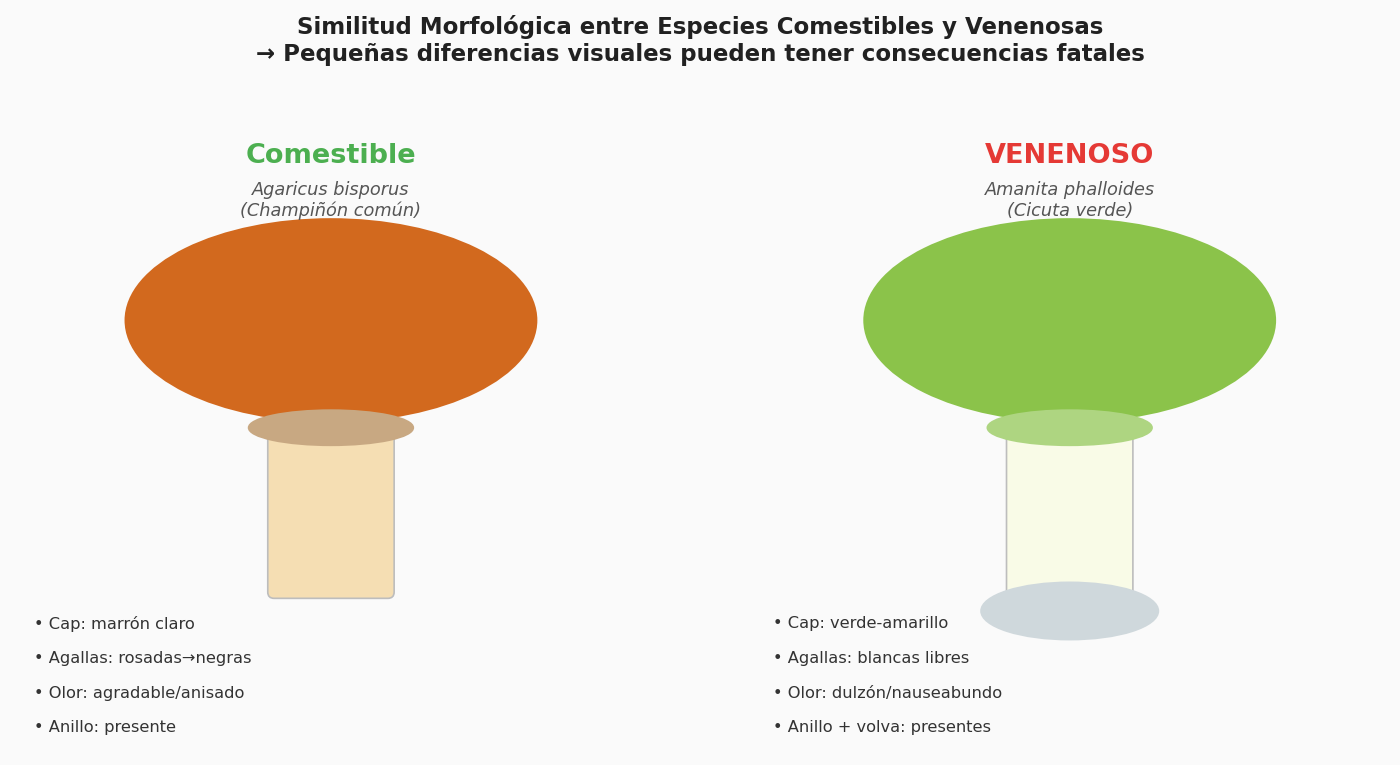

Imagen guardada: mushroom_comparison.png


In [ ]:
def generate_mushroom_comparison():
    """
    Genera una figura ilustrativa (mushroom_comparison.png) que muestra
    la dificultad de distinguir hongos comestibles de venenosos basándose
    solo en características visuales similares.
    Se usan iconos esquemáticos vectoriales; no se requieren imágenes externas.
    """
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    fig.patch.set_facecolor("#FAFAFA")

    species = [
        {
            "ax": axes[0],
            "label": "Comestible",
            "subtitle": "Agaricus bisporus\n(Champiñón común)",
            "cap_color": "#D2691E",
            "stem_color": "#F5DEB3",
            "ring_color": "#C8A882",
            "bg": "#E8F5E9",
            "border": "#4CAF50",
            "features": ["Cap: marrón claro", "Agallas: rosadas→negras",
                         "Olor: agradable/anisado", "Anillo: presente"],
        },
        {
            "ax": axes[1],
            "label": "VENENOSO",
            "subtitle": "Amanita phalloides\n(Cicuta verde)",
            "cap_color": "#8BC34A",
            "stem_color": "#F9FBE7",
            "ring_color": "#AED581",
            "bg": "#FFEBEE",
            "border": "#E53935",
            "features": ["Cap: verde-amarillo", "Agallas: blancas libres",
                         "Olor: dulzón/nauseabundo", "Anillo + volva: presentes"],
        },
    ]

    for sp in species:
        ax = sp["ax"]
        ax.set_facecolor(sp["bg"])
        ax.set_xlim(0, 10)
        ax.set_ylim(0, 10)
        ax.set_aspect("equal")
        ax.axis("off")
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color(sp["border"])
            spine.set_linewidth(3)

        # Sombrero (cap) — semicírculo
        cap = mpatches.Ellipse((5, 6.8), width=6.5, height=3.2,
                                color=sp["cap_color"], zorder=3)
        ax.add_patch(cap)
        # Tallo (stem)
        stem = mpatches.FancyBboxPatch((4.1, 2.5), 1.8, 4.2,
                                        boxstyle="round,pad=0.1",
                                        color=sp["stem_color"],
                                        ec="#BDBDBD", lw=0.8, zorder=2)
        ax.add_patch(stem)
        # Anillo
        ring = mpatches.Ellipse((5, 5.1), width=2.6, height=0.55,
                                  color=sp["ring_color"], zorder=4)
        ax.add_patch(ring)
        # Volva (solo para Amanita)
        if sp["label"] == "VENENOSO":
            volva = mpatches.Ellipse((5, 2.2), width=2.8, height=0.9,
                                      color="#CFD8DC", zorder=2)
            ax.add_patch(volva)

        # Etiquetas de texto
        ax.text(5, 9.4, sp["label"], ha="center", va="center",
                fontsize=13, fontweight="bold",
                color=sp["border"])
        ax.text(5, 8.7, sp["subtitle"], ha="center", va="center",
                fontsize=8.5, style="italic", color="#555555")

        # Lista de características
        for i, feat in enumerate(sp["features"]):
            ax.text(0.3, 2.0 - i*0.55, f"• {feat}", ha="left", va="center",
                    fontsize=7.8, color="#333333")

    fig.suptitle(
        "Similitud Morfológica entre Especies Comestibles y Venenosas\n"
        "→ Pequeñas diferencias visuales pueden tener consecuencias fatales",
        fontsize=11, fontweight="bold", color="#212121", y=1.01
    )
    plt.tight_layout()
    plt.savefig("mushroom_comparison.png", bbox_inches="tight", dpi=150)
    plt.show()
    print("Imagen guardada: mushroom_comparison.png")

generate_mushroom_comparison()

## 5. Preprocesamiento

In [ ]:
def preprocess_data(X, y):
    """
    Pipeline de preprocesamiento:
      1. Elimina características sin varianza (veil-type).
      2. Imputa valores faltantes con la moda (stalk-root).
      3. Aplica One-Hot Encoding a todas las variables categóricas.
      4. Codifica la variable objetivo a binario (0=comestible, 1=venenoso).
    """
    print("\n" + "="*50)
    print("PREPROCESAMIENTO")
    print("="*50)

    X_proc = X.copy()

    # 1. Eliminar características sin varianza predictiva
    cols_drop = X_proc.nunique()[X_proc.nunique() == 1].index.tolist()
    if cols_drop:
        print(f"Eliminando (varianza cero): {cols_drop}")
        X_proc.drop(columns=cols_drop, inplace=True)

    # 2. Imputación con la moda
    print("Imputando valores faltantes con la moda...")
    imputer = SimpleImputer(strategy="most_frequent")
    X_proc = pd.DataFrame(imputer.fit_transform(X_proc), columns=X_proc.columns)

    # 3. One-Hot Encoding
    print("Aplicando One-Hot Encoding...")
    X_enc = pd.get_dummies(X_proc, drop_first=True)

    # 4. Codificación de la variable objetivo
    le = LabelEncoder()
    y_enc = le.fit_transform(y)
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"Mapeo objetivo: {mapping}")

    print(f"\n Preprocesamiento finalizado: {X_enc.shape[0]} muestras × {X_enc.shape[1]} características")
    return X_enc, y_enc

X_clean, y_clean = preprocess_data(X_raw, y_raw)


PREPROCESAMIENTO
Eliminando (varianza cero): ['veil-type']
Imputando valores faltantes con la moda...
Aplicando One-Hot Encoding...
Mapeo objetivo: {'e': np.int64(0), 'p': np.int64(1)}

 Preprocesamiento finalizado: 8124 muestras × 94 características


## 6. Entrenamiento y Evaluación de Modelos

In [ ]:
def train_and_evaluate_models(X, y, n_splits=N_SPLITS):
    """
    Entrena cuatro modelos con validación cruzada estratificada (k=5).
    Retorna: DataFrame de métricas consolidadas y dict de modelos entrenados.
    """
    print("\n" + "="*50)
    print("ENTRENAMIENTO Y EVALUACIÓN")
    print("="*50)
    print(f"Validación Cruzada Estratificada — {n_splits} pliegues\n")

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

    models = {
        "Regresión Logística":  LogisticRegression(C=1.0, solver="lbfgs",
                                                    max_iter=1000,
                                                    random_state=RANDOM_STATE),
        "Random Forest":        RandomForestClassifier(n_estimators=100,
                                                        random_state=RANDOM_STATE),
        "SVM":                  SVC(kernel="rbf", random_state=RANDOM_STATE),
        "Perceptrón Multicapa": MLPClassifier(hidden_layer_sizes=(100,),
                                               max_iter=1000,
                                               random_state=RANDOM_STATE),
    }

    results   = []
    cm_accum  = {name: np.zeros((2, 2)) for name in models}

    for name, model in models.items():
        print(f"Evaluando: {name}...")
        acc_l, prec_l, rec_l, f1_l = [], [], [], []

        for train_idx, test_idx in skf.split(X, y):
            X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
            y_tr, y_te = y[train_idx], y[test_idx]

            model.fit(X_tr, y_tr)
            y_pred = model.predict(X_te)

            acc_l.append(accuracy_score(y_te, y_pred))
            prec_l.append(precision_score(y_te, y_pred, zero_division=0))
            rec_l.append(recall_score(y_te, y_pred, zero_division=0))
            f1_l.append(f1_score(y_te, y_pred, zero_division=0))
            cm_accum[name] += confusion_matrix(y_te, y_pred)

        results.append({
            "Modelo":                  name,
            "Exactitud":               f"{np.mean(acc_l):.4f} ± {np.std(acc_l):.4f}",
            "Precisión":               f"{np.mean(prec_l):.4f} ± {np.std(prec_l):.4f}",
            "Sensibilidad (Recall)*":  f"{np.mean(rec_l):.4f} ± {np.std(rec_l):.4f}",
            "F1-Score":                f"{np.mean(f1_l):.4f} ± {np.std(f1_l):.4f}",
        })

    df = pd.DataFrame(results)
    print("\n Resultados de validación cruzada (media ± desv. estándar):")
    print("   * Sensibilidad: capacidad de detectar hongos venenosos (Clase 1)\n")
    print(df.to_string(index=False))

    return df, models, cm_accum

df_metrics, trained_models, cm_accum = train_and_evaluate_models(X_clean, y_clean)


ENTRENAMIENTO Y EVALUACIÓN
Validación Cruzada Estratificada — 5 pliegues

Evaluando: Regresión Logística...
Evaluando: Random Forest...
Evaluando: SVM...
Evaluando: Perceptrón Multicapa...

 Resultados de validación cruzada (media ± desv. estándar):
   * Sensibilidad: capacidad de detectar hongos venenosos (Clase 1)

              Modelo       Exactitud       Precisión Sensibilidad (Recall)*        F1-Score
 Regresión Logística 0.9995 ± 0.0007 1.0000 ± 0.0000        0.9990 ± 0.0015 0.9995 ± 0.0007
       Random Forest 1.0000 ± 0.0000 1.0000 ± 0.0000        1.0000 ± 0.0000 1.0000 ± 0.0000
                 SVM 1.0000 ± 0.0000 1.0000 ± 0.0000        1.0000 ± 0.0000 1.0000 ± 0.0000
Perceptrón Multicapa 1.0000 ± 0.0000 1.0000 ± 0.0000        1.0000 ± 0.0000 1.0000 ± 0.0000


## 7. Visualización: Matrices de Confusión

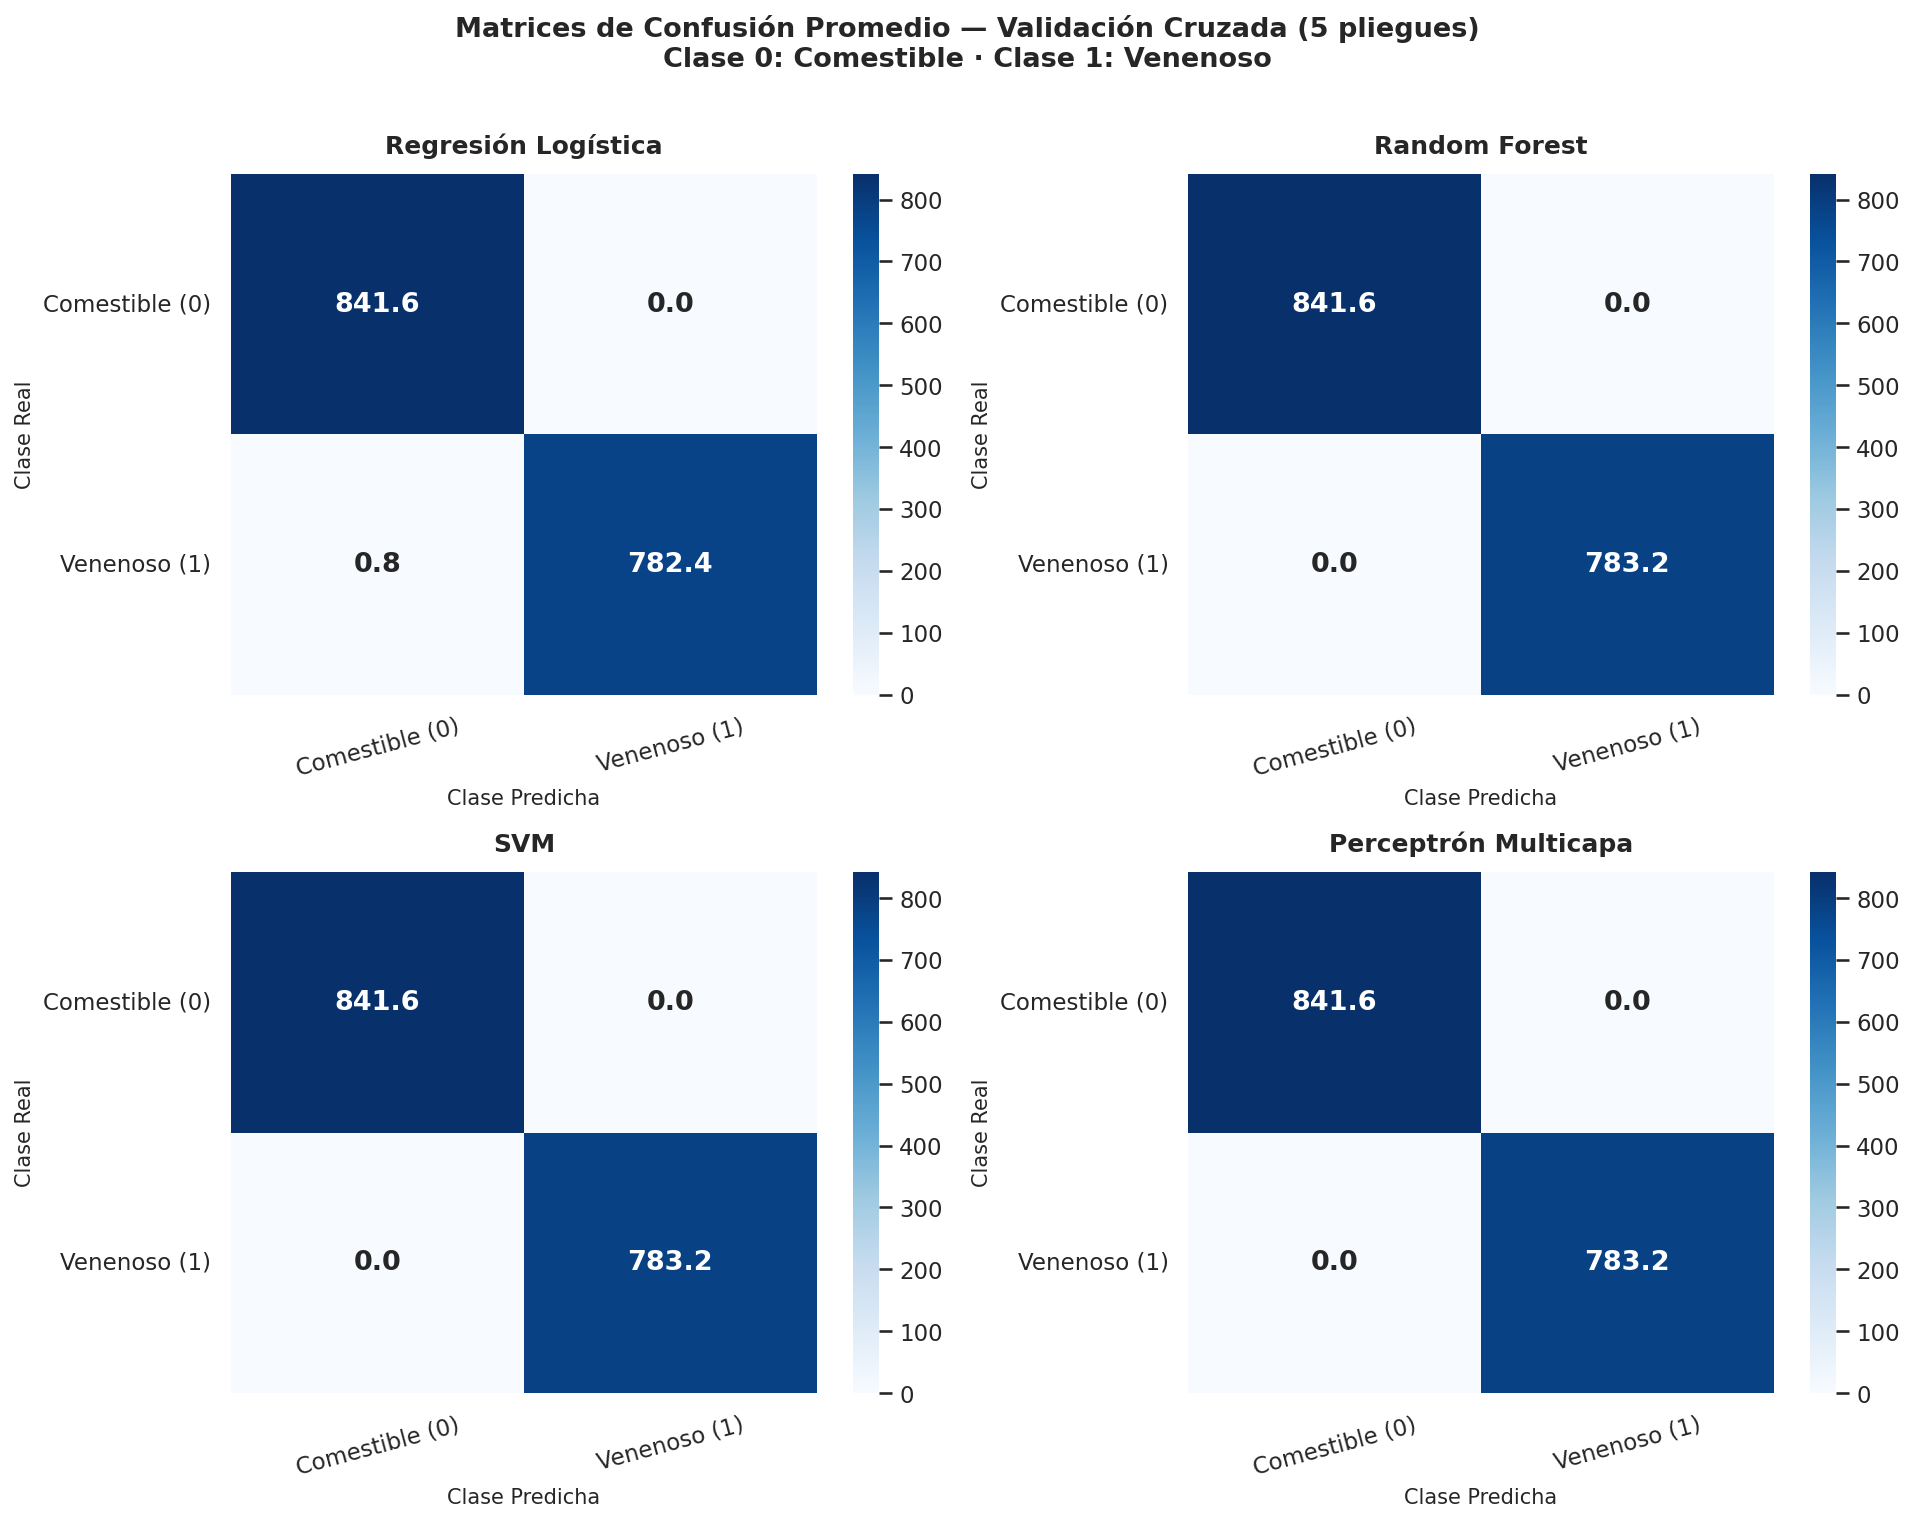

Imagen guardada: confusion_matrices.png


In [ ]:
def plot_confusion_matrices(cm_accum, n_splits=N_SPLITS, save_path="confusion_matrices.png"):
    """
    Genera y guarda el panel 2×2 de matrices de confusión promediadas
    sobre los pliegues de validación cruzada.
    """
    names  = list(cm_accum.keys())
    fig, axes = plt.subplots(2, 2, figsize=(13, 10))
    axes = axes.ravel()

    class_labels = ["Comestible (0)", "Venenoso (1)"]

    for i, (name, matrix) in enumerate(cm_accum.items()):
        avg_matrix = matrix / n_splits
        sns.heatmap(avg_matrix, annot=True, fmt=".1f",
                    cmap="Blues", ax=axes[i], cbar=True,
                    xticklabels=class_labels,
                    yticklabels=class_labels,
                    annot_kws={"size": 13, "weight": "bold"})
        axes[i].set_title(f"{name}", fontsize=12, fontweight="bold", pad=10)
        axes[i].set_ylabel("Clase Real",    fontsize=10)
        axes[i].set_xlabel("Clase Predicha", fontsize=10)
        axes[i].tick_params(axis="x", rotation=15)
        axes[i].tick_params(axis="y", rotation=0)

    fig.suptitle(
        "Matrices de Confusión Promedio — Validación Cruzada (5 pliegues)\n"
        "Clase 0: Comestible · Clase 1: Venenoso",
        fontsize=13, fontweight="bold", y=1.01
    )
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight", dpi=150)
    plt.show()
    print(f"Imagen guardada: {save_path}")

plot_confusion_matrices(cm_accum)

## 8. Pipeline Completo (Ejecución Secuencial)

Descargando el dataset Mushroom desde OpenML (ID: 24)...
¡Descarga completada!  →  8124 muestras, 22 características.

EXPLORACIÓN DE DATOS
Dimensiones iniciales: 8124 muestras × 22 características

 Valores faltantes:
stalk-root    2480
dtype: int64


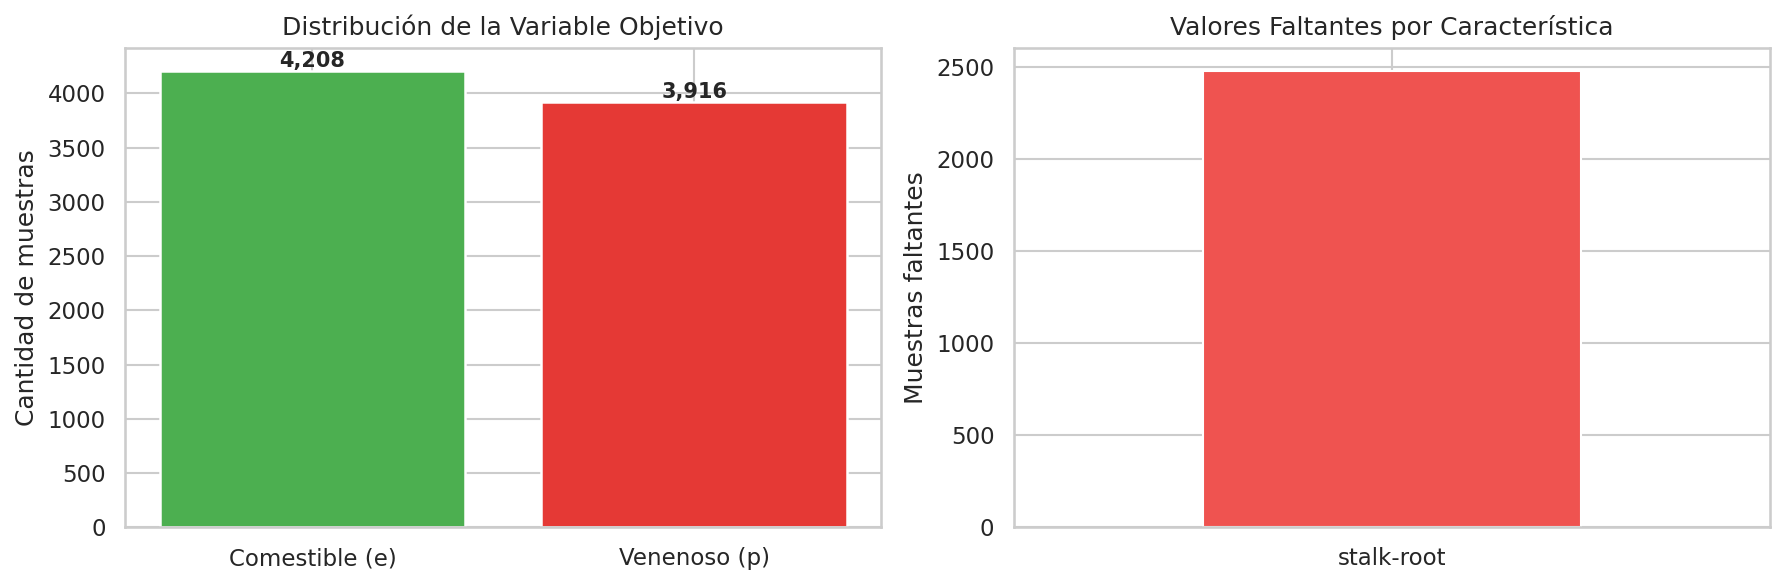


 Características con un solo valor (se eliminarán): ['veil-type']


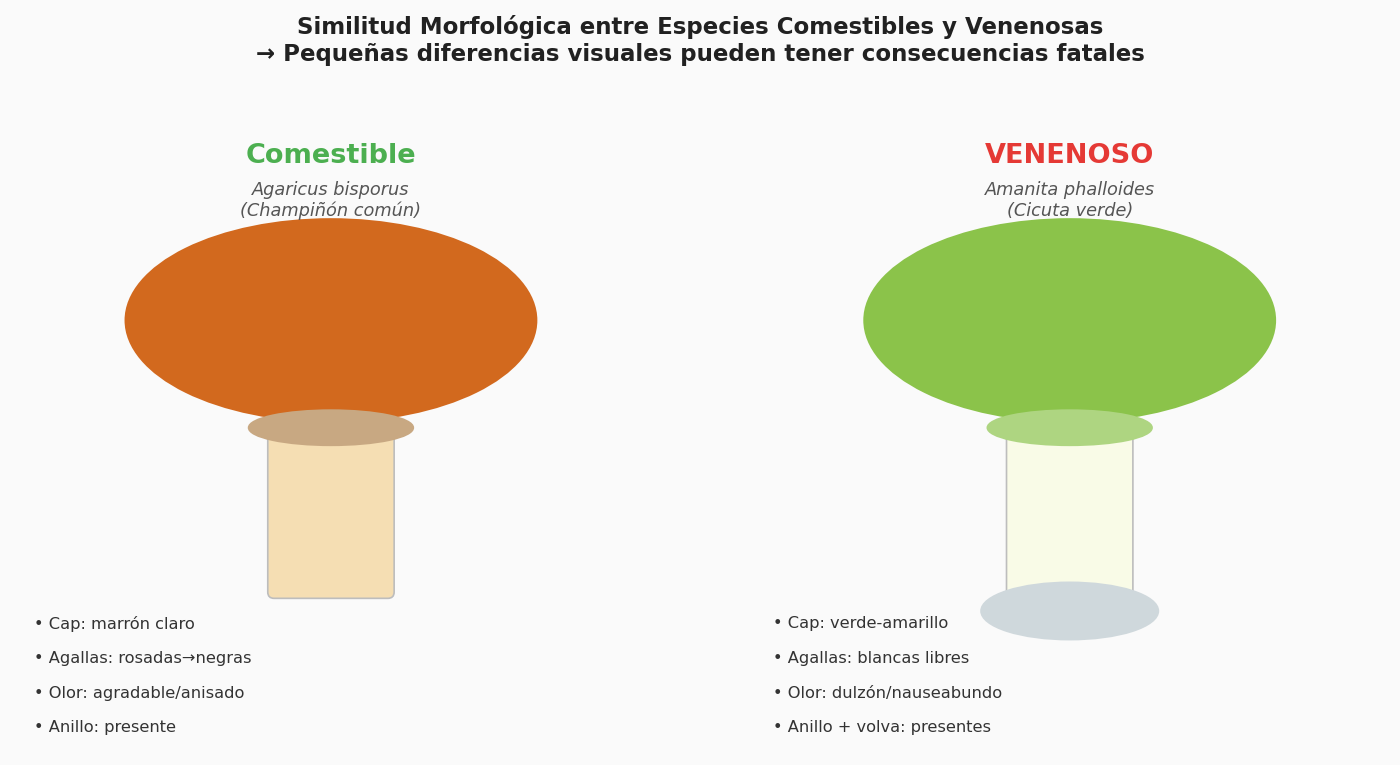

Imagen guardada: mushroom_comparison.png

PREPROCESAMIENTO
Eliminando (varianza cero): ['veil-type']
Imputando valores faltantes con la moda...
Aplicando One-Hot Encoding...
Mapeo objetivo: {'e': np.int64(0), 'p': np.int64(1)}

 Preprocesamiento finalizado: 8124 muestras × 94 características

ENTRENAMIENTO Y EVALUACIÓN
Validación Cruzada Estratificada — 5 pliegues

Evaluando: Regresión Logística...
Evaluando: Random Forest...
Evaluando: SVM...
Evaluando: Perceptrón Multicapa...

 Resultados de validación cruzada (media ± desv. estándar):
   * Sensibilidad: capacidad de detectar hongos venenosos (Clase 1)

              Modelo       Exactitud       Precisión Sensibilidad (Recall)*        F1-Score
 Regresión Logística 0.9995 ± 0.0007 1.0000 ± 0.0000        0.9990 ± 0.0015 0.9995 ± 0.0007
       Random Forest 1.0000 ± 0.0000 1.0000 ± 0.0000        1.0000 ± 0.0000 1.0000 ± 0.0000
                 SVM 1.0000 ± 0.0000 1.0000 ± 0.0000        1.0000 ± 0.0000 1.0000 ± 0.0000
Perceptrón Multicap

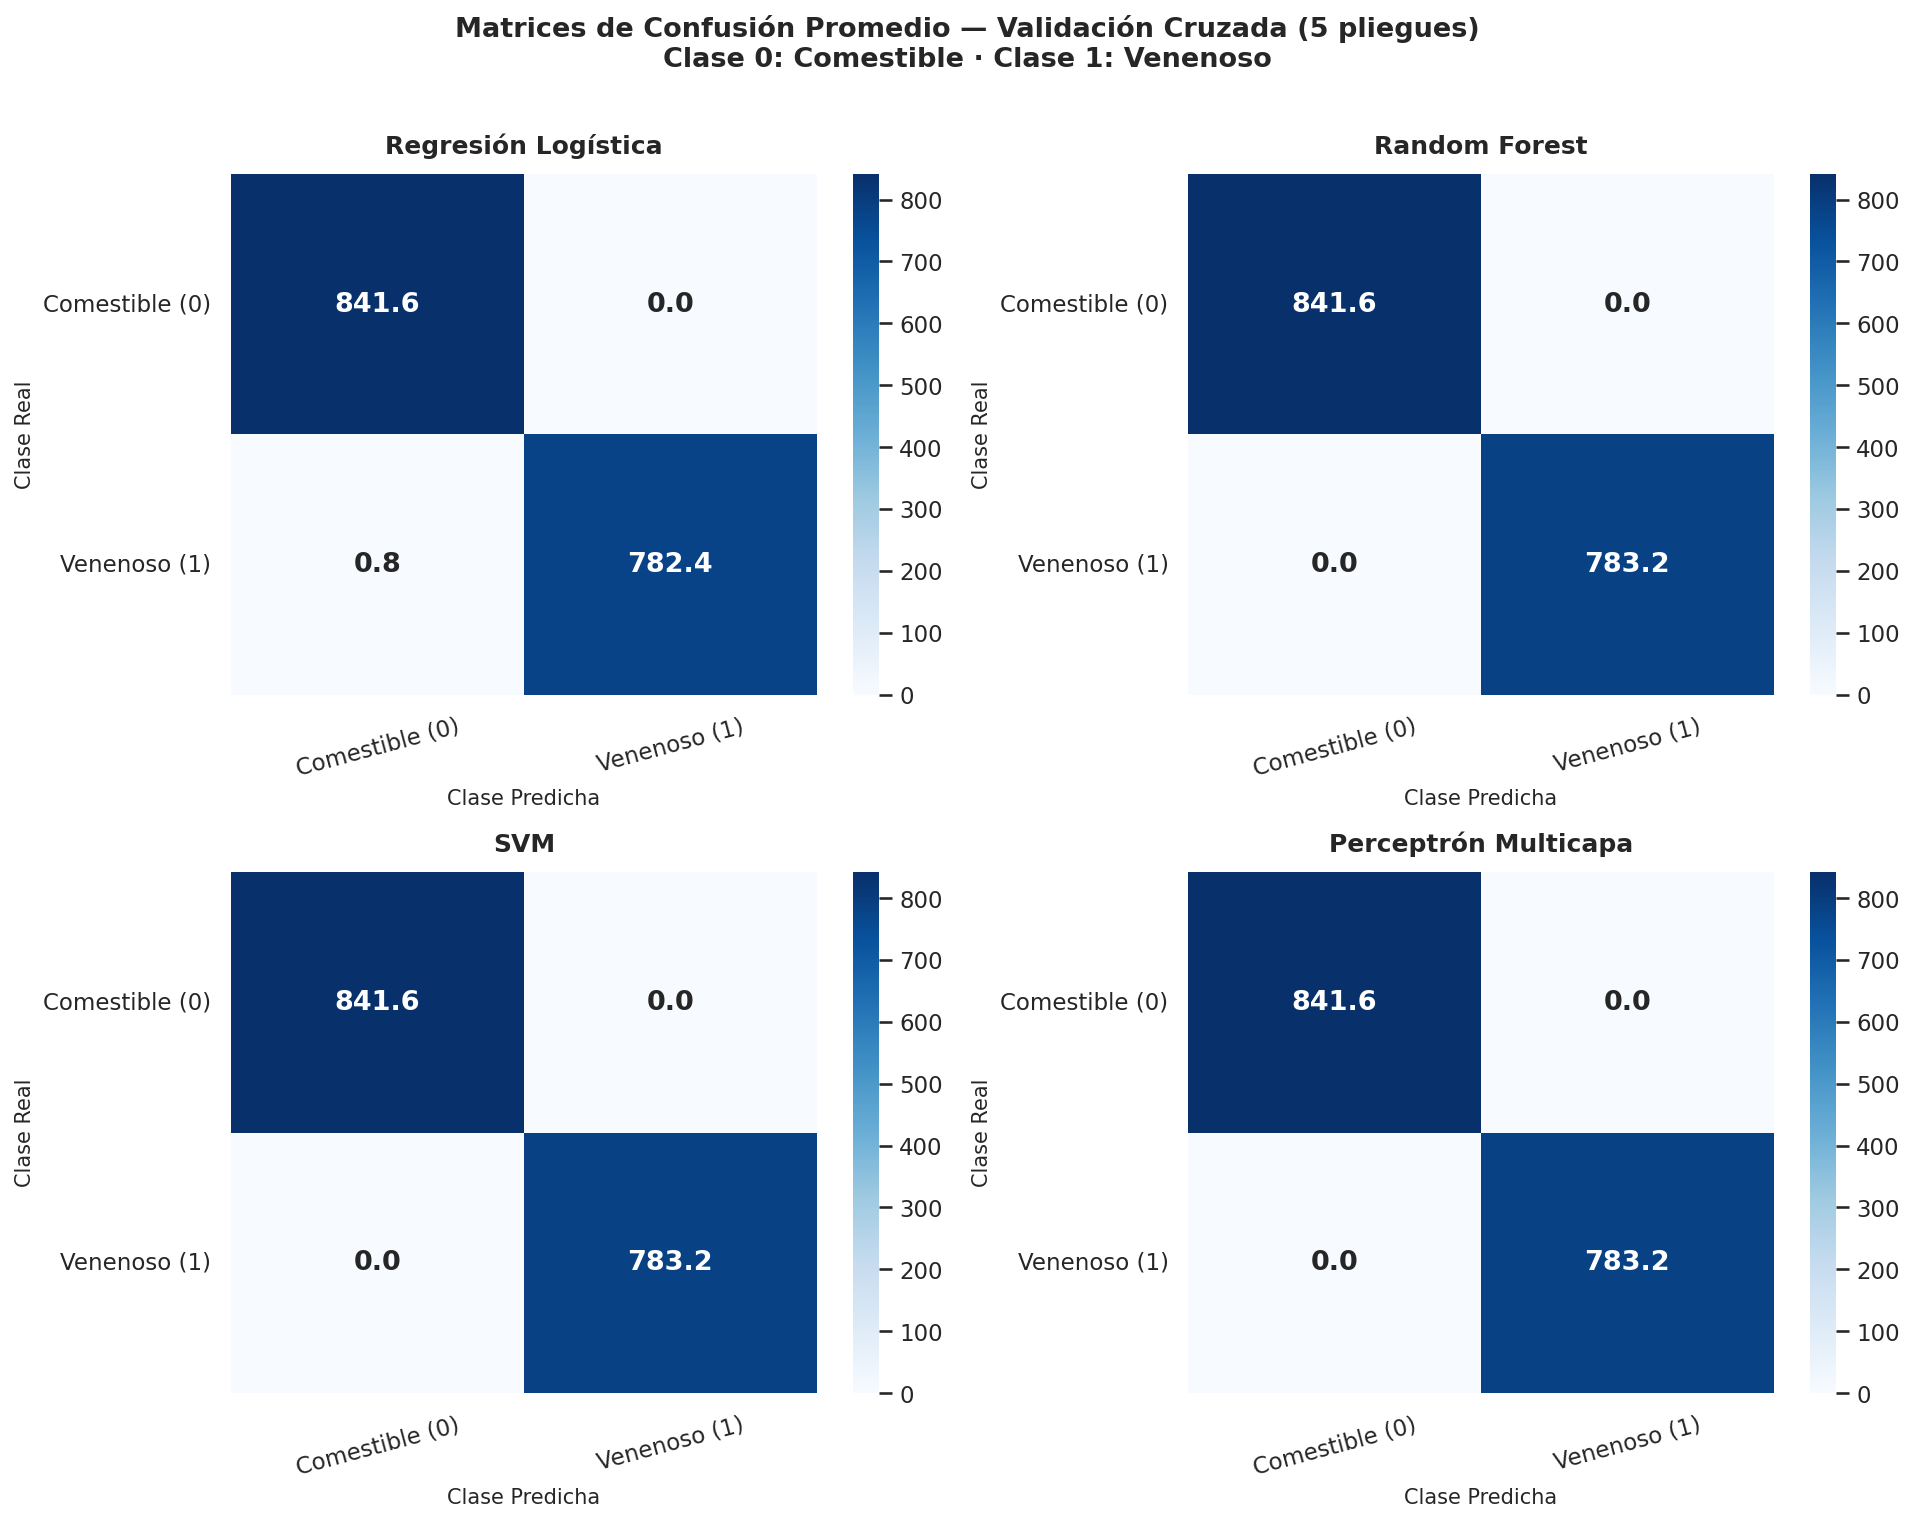

Imagen guardada: confusion_matrices.png

 Pipeline completado. Imágenes listas para el informe LaTeX.


In [ ]:
# Este bloque ejecuta todo el pipeline de forma ordenada.
# Útil para re-ejecutar el notebook limpio de arriba a abajo.
if __name__ == "__main__":
    # 1. Carga
    X_raw, y_raw = load_data()
    # 2. Exploración
    explore_data(X_raw, y_raw)
    # 3. Imagen comparativa
    generate_mushroom_comparison()
    # 4. Preprocesamiento
    X_clean, y_clean = preprocess_data(X_raw, y_raw)
    # 5. Entrenamiento y evaluación
    df_metrics, trained_models, cm_accum = train_and_evaluate_models(X_clean, y_clean)
    # 6. Matrices de confusión
    plot_confusion_matrices(cm_accum)
    print("\n Pipeline completado. Imágenes listas para el informe LaTeX.")